# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

*Presentado por:*
- Shaiel Jiménez - 202323846
- Juan Esteban Triviño - 202315338

*ISIS2611 - Aprendizaje de Máquina / Sección 5*

*Profesor: Rubén Manrique*


**Contenido**

1. [Introducción](#introduccion)
2. [Carga de datos limpios](#datos)
3. [Actividad 1 — Regresión polinomial](#actividad1)
4. [Actividad 2 — Curvas de validación](#actividad2)
5. [Actividad 3 — Regresión regularizada (Ridge / Lasso)](#actividad3)
6. [Actividad 4 — Regresión polinomial regularizada](#actividad4)
7. [Actividad 5 — Comparación y selección del mejor modelo](#actividad5)
8. [Actividad 6 — Intervalos de confianza (bootstrapping)](#actividad6)
9. [Análisis de resultados](#analisis)
10. [Uso de herramientas de IA generativa](#iag)


## <a id="introduccion"></a> Introducción

En el [Laboratorio 1](../ISIS2611-Laboratorio1) se construyó un primer modelo de regresión
lineal para AlpesPlanck y se identificaron las variables más influyentes en la estimación de
la temperatura máxima del día siguiente (`temp_max_manana`). En este laboratorio se amplía
ese trabajo: se comparan enfoques de mayor complejidad (regresión polinomial y regularizada),
se estudia el trade-off sesgo-varianza mediante curvas de validación, se realiza búsqueda
sistemática de hiperparámetros con `GridSearchCV`, y se cuantifica la incertidumbre del
modelo final mediante bootstrapping.

**Nota metodológica.** El enunciado indica explícitamente que el énfasis de este laboratorio
no está en la exploración ni en la limpieza de los datos, sino en el modelado y la validación.
Por eso la limpieza (corrección de categorías, errores de escala, duplicados, outliers
imposibles e imputación sin fuga de datos) se reutiliza del Laboratorio 1 y se encapsula en
[`src/data_prep.py`](../src/data_prep.py); este notebook parte directamente de los conjuntos
`X_train`/`X_test` ya limpios.

> **TODO:** completar aquí, en 2-3 líneas, el resumen de decisiones metodológicas propias
> de este laboratorio (qué se comparó y por qué), una vez estén los resultados de las
> actividades 1 a 6.


## Configuración del entorno

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, validation_curve, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils import resample

sys.path.append(str(Path.cwd()))  # permite importar el paquete `src` desde la raíz del repo

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# KFold explícito (shuffle=True + random_state) para las búsquedas de las Actividades 3 en
# adelante, siguiendo la misma convención de la práctica de clase de regresión regularizada.
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## <a id="datos"></a> Carga de datos limpios

Se reutiliza el pipeline de limpieza del Laboratorio 1 (`src/data_prep.py`), que aplica sobre
los datos crudos: corrección de categorías inconsistentes (`mes`, `estacion_anio`,
`sector_viento`), corrección de errores de escala (`presion_media`, `humedad_media`,
`humedad_min`), eliminación de duplicados y de outliers físicamente imposibles, eliminación de
filas sin variable objetivo, y separación train/test (75/25, `random_state=42`) **antes** de
imputar nulos (mediana para numéricas, moda para categóricas, ajustado solo con `X_train`) para
evitar fuga de datos.

In [3]:
from src.data_prep import cargar_datos_limpios

X_train, X_test, y_train, y_test = cargar_datos_limpios()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Nulos en X_train: {X_train.isna().sum().sum()} | Nulos en X_test: {X_test.isna().sum().sum()}")
X_train.head()


X_train: (1742, 26) | X_test: (581, 26)
Nulos en X_train: 0 | Nulos en X_test: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
668,2011-01-01,990.4306,988.27,994.61,1.6986,87.9715,58.50,93.5,3.2908,2.50170,...,1.0125,-0.9174,-1.1860,232.2759,144.0,2011.0,1.0,invierno,enero,SO
205,2009-08-15,990.9322,988.86,992.65,1.4017,61.2281,33.60,95.2,21.8682,7.04088,...,-80.8750,-1.6241,-0.6097,200.5760,144.0,2009.0,227.0,invierno,julio,S
807,2011-06-02,1003.7751,1002.37,1005.08,0.7741,50.1300,33.96,70.3,11.7444,3.06400,...,2.4807,2.4297,1.5834,33.0913,144.0,2011.0,153.0,verano,diciembre,NE
2251,2015-10-26,996.8902,994.37,999.64,1.7672,88.1743,74.00,96.1,6.8894,6.72084,...,-56.4650,1.3131,1.0971,39.8797,144.0,2015.0,299.0,otono,septiembre,NE
557,2010-09-01,992.1408,991.32,993.17,0.3805,84.4896,73.20,93.5,4.7864,1.80630,...,1.1314,-0.5128,-1.4898,251.0061,144.0,2010.0,244.0,otono,septiembre,O


In [4]:
# Variables numéricas y categóricas usadas en los pipelines de este laboratorio
# (misma convención que el Laboratorio 1: 'fecha' queda fuera al no ser numérica ni
# estar en la lista de categóricas, y el ColumnTransformer la descarta por defecto).
categorical_features = ["mes", "estacion_anio", "sector_viento"]
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Variables numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Variables categóricas ({len(categorical_features)}): {categorical_features}")


Variables numéricas (22): ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio']
Variables categóricas (3): ['mes', 'estacion_anio', 'sector_viento']


### Utilidades reutilizables

Estas funciones se usan a lo largo de todas las actividades (evaluación de métricas,
graficación de curvas de validación, extracción de coeficientes y bootstrapping), para no
repetir la misma lógica en cada modelo. Por convención, todos los pipelines de este notebook
deben nombrar sus pasos `"preprocesamiento"` y `"regresor"`.

In [5]:
resultados_modelos = []  # aquí se van acumulando las métricas de cada modelo (Actividad 5)


def evaluar_modelo(nombre, estimator, X_train, y_train, X_test, y_test, resultados=resultados_modelos):
    """Calcula RMSE, MAE y R² en train y test para un estimador ya ajustado
    y guarda el resultado en `resultados` (por defecto, `resultados_modelos`)."""
    y_train_pred = estimator.predict(X_train)
    y_test_pred = estimator.predict(X_test)

    metricas = {
        "modelo": nombre,
        "RMSE_train": mean_squared_error(y_train, y_train_pred) ** 0.5,
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "R2_train": r2_score(y_train, y_train_pred),
        "RMSE_test": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "MAE_test": mean_absolute_error(y_test, y_test_pred),
        "R2_test": r2_score(y_test, y_test_pred),
    }
    if resultados is not None:
        resultados.append(metricas)
    return metricas


def resumen_cv(grid, nombre):
    """Extrae el promedio y desviación estándar (en validación cruzada) del mejor
    conjunto de hiperparámetros encontrado por un GridSearchCV ya ajustado.
    Asume scoring='neg_root_mean_squared_error'."""
    idx = grid.best_index_
    return {
        "modelo": nombre,
        "mejores_hiperparametros": grid.best_params_,
        "RMSE_cv_mean": -grid.cv_results_["mean_test_score"][idx],
        "RMSE_cv_std": grid.cv_results_["std_test_score"][idx],
    }


def obtener_coeficientes(pipeline):
    """Devuelve un DataFrame con el nombre de cada variable transformada y su
    coeficiente, ordenado por magnitud absoluta descendente."""
    nombres = pipeline.named_steps["preprocesamiento"].get_feature_names_out()
    coefs = pipeline.named_steps["regresor"].coef_
    return (
        pd.DataFrame({"variable": nombres, "coeficiente": coefs})
        .assign(coef_abs=lambda d: d["coeficiente"].abs())
        .sort_values("coef_abs", ascending=False)
        .reset_index(drop=True)
    )


def graficar_curva_validacion(param_range, train_scores, test_scores, xlabel, titulo, log_scale=False):
    """Grafica el score promedio ± 1 desviación estándar en train y en validación
    cruzada, en función de un hiperparámetro (p. ej. el grado del polinomio).

    `log_scale=True` usa escala logarítmica en el eje Y: útil cuando el error se
    dispara varios órdenes de magnitud (p. ej. al comparar grados de un polinomio
    que van desde un ajuste razonable hasta un colapso por sobreajuste), donde una
    escala lineal aplastaría las diferencias finas de los grados bajos.
    """
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_mean, label="Train", color="#4c72b0", marker="o")
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="#4c72b0")
    plt.plot(param_range, test_mean, label="Validación (CV)", color="#dd8452", marker="o")
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="#dd8452")
    plt.xlabel(xlabel)
    plt.ylabel("RMSE" + (" (escala log)" if log_scale else ""))
    plt.title(titulo)
    if log_scale:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()


def bootstrap_metricas(modelo, X_test, y_test, n_iteraciones=500, random_state=RANDOM_STATE):
    """Remuestrea (con reemplazo) el conjunto de test `n_iteraciones` veces y calcula
    RMSE, MAE y R² en cada remuestreo. Devuelve un DataFrame con una fila por remuestreo."""
    rng = np.random.RandomState(random_state)
    X_test = X_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    filas = []
    for _ in range(n_iteraciones):
        idx = rng.randint(0, len(X_test), len(X_test))
        X_boot, y_boot = X_test.iloc[idx], y_test.iloc[idx]
        y_pred = modelo.predict(X_boot)
        filas.append({
            "RMSE": mean_squared_error(y_boot, y_pred) ** 0.5,
            "MAE": mean_absolute_error(y_boot, y_pred),
            "R2": r2_score(y_boot, y_pred),
        })
    return pd.DataFrame(filas)


def intervalo_confianza(muestras, nivel=0.95):
    alpha = (1 - nivel) / 2
    return muestras.quantile(alpha), muestras.quantile(1 - alpha)


def graficar_distribucion_bootstrap(boot_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metrica in zip(axes, ["RMSE", "MAE", "R2"]):
        sns.histplot(boot_df[metrica], kde=True, ax=ax, color="#55a868")
        ax.axvline(boot_df[metrica].mean(), color="red", linestyle="--", label="media")
        ax.set_title(metrica)
        ax.legend()
    plt.tight_layout()
    plt.show()


## <a id="actividad1"></a> Actividad 1 — Regresión polinomial

**Qué pide el enunciado:** un pipeline con generación de características polinomiales +
regresión lineal, con búsqueda de hiperparámetros mediante `GridSearchCV` explorando el
**grado del polinomio** y **distintas estrategias de escalamiento**, reportando RMSE, MAE y
R², y analizando cómo cambia el desempeño (y el sobreajuste) al aumentar la complejidad.

**Decisiones de diseño.**

- **Grados explorados: 1 a 4.** El grado 1 es el caso base (una regresión lineal simple,
  equivalente a un modelo del Laboratorio 1). Con 22 variables numéricas, `PolynomialFeatures`
  genera 22, 275, 2299 y 14949 columnas para los grados 1 a 4 respectivamente. A partir de
  grado 3 ya hay más columnas que filas de entrenamiento por fold (~1393), así que se espera
  ver sobreajuste severo dentro de este mismo rango, en vez de tener que adivinar un rango más
  amplio.
- **Escaladores comparados: `StandardScaler` y `MinMaxScaler`.** Para una regresión lineal
  pura sin regularización, el escalador no cambia las predicciones (mínimos cuadrados
  encuentra el mismo hiperplano, solo cambia la escala de los coeficientes); lo que sí puede
  cambiar es la estabilidad numérica del ajuste cuando el número de columnas generadas es muy
  alto, por lo que conviene confirmarlo empíricamente y no darlo por sentado.
- **`cv=5`**: balance estándar entre varianza de la estimación (más folds) y costo
  computacional (menos folds).
- **`scoring="neg_root_mean_squared_error"`**: `GridSearchCV` siempre maximiza el score
  internamente, así que una métrica de error como RMSE debe pasarse en negativo para que
  "mejor" (score más alto) siga significando "menor error".

In [6]:
preprocesamiento_poly = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),  # valor inicial; el grid de abajo prueba ambas opciones
    ]), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

pipeline_poly = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly),
    ("regresor", LinearRegression()),
])

param_grid_poly = {
    "preprocesamiento__num__poly__degree": [1, 2, 3, 4],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
}

grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)

grid_poly.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_poly.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_poly.best_score_:.3f}")


Mejores hiperparámetros: {'preprocesamiento__num__poly__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE promedio en validación cruzada: 6.967


In [7]:
# Resumen de la búsqueda: RMSE (train y validación) por grado y escalador
resumen_grid_poly = (
    pd.DataFrame(grid_poly.cv_results_)
    .loc[:, [
        "param_preprocesamiento__num__poly__degree",
        "param_preprocesamiento__num__scaler",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
    ]]
    .rename(columns={
        "param_preprocesamiento__num__poly__degree": "grado",
        "param_preprocesamiento__num__scaler": "escalador",
        "mean_train_score": "RMSE_cv_train",
        "mean_test_score": "RMSE_cv_val",
        "std_test_score": "RMSE_cv_val_std",
    })
    .assign(
        RMSE_cv_train=lambda d: -d["RMSE_cv_train"],
        RMSE_cv_val=lambda d: -d["RMSE_cv_val"],
    )
    .sort_values("grado")
    .reset_index(drop=True)
)
resumen_grid_poly


,grado,escalador,RMSE_cv_train,RMSE_cv_val,RMSE_cv_val_std
0,1,StandardScaler(),6.699574e+00,6.967166,0.433745
1,1,MinMaxScaler(),6.699574e+00,6.967166,0.433745
2,2,StandardScaler(),4.379621e+00,8.150377,1.426953
3,2,MinMaxScaler(),4.379621e+00,9.990556,4.884804
4,3,StandardScaler(),9.200306e-01,2090.227476,1422.795341
5,3,MinMaxScaler(),1.014478e+00,996.346442,606.850057
6,4,StandardScaler(),1.263073e-12,257.761535,113.958727
7,4,MinMaxScaler(),9.343679e-12,174.955292,69.563313


In [8]:
evaluar_modelo(
    "Regresión polinomial (GridSearchCV)", grid_poly.best_estimator_, X_train, y_train, X_test, y_test
)
pd.DataFrame(resultados_modelos).set_index("modelo")


,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
modelo,,,,,,
Regresión polinomial (GridSearchCV),6.727844,5.091492,0.479034,6.346607,5.094928,0.476326


**Análisis (Actividad 1).**

El mejor modelo según validación cruzada es el de **grado 1** (RMSE_cv ≈ 6.97), es decir, sin
ninguna expansión polinomial. En grado 1 ambos escaladores dan exactamente el mismo RMSE, tal
como se esperaba: escalar las variables no cambia el hiperplano que ajusta mínimos cuadrados
en una regresión lineal sin regularización.

A partir de grado 2 el desempeño ya empeora en validación cruzada (RMSE_cv sube a ~8.2-10.0)
aunque el error de entrenamiento baja (~4.4): la primera señal clara de sobreajuste, el modelo
empieza a ajustar ruido de train en vez de señal generalizable. En grado 3 el colapso es
total: el error de entrenamiento cae a ~0.9-1.0 (el modelo casi memoriza los datos — tiene
2299 columnas generadas contra ~1393 filas por fold de entrenamiento) pero el RMSE de
validación se dispara a 996-2090. En grado 4 (14949 columnas) el error de entrenamiento es
prácticamente 0 (ajuste perfecto / interpolación) y el error de validación, aunque algo menor
que en grado 3, sigue siendo enorme (175-258).

Este patrón es el trade-off sesgo-varianza de manual: al subir la complejidad, el sesgo baja
(el modelo ajusta cada vez mejor el training set) pero la varianza se dispara sin control,
porque no hay ningún mecanismo que limite la magnitud de los coeficientes. Esto motiva
directamente las Actividades 3 y 4, donde se prueba si Ridge/Lasso permiten usar grados más
altos sin este colapso.

En test, el modelo final (grado 1) obtiene RMSE ≈ 6.35, MAE ≈ 5.09, R² ≈ 0.48 — muy similar a
sus métricas de entrenamiento (RMSE ≈ 6.73, R² ≈ 0.48), sin señales de sobreajuste, consistente
con haber sido el ganador en validación cruzada.

## <a id="actividad2"></a> Actividad 2 — Curvas de validación

**Qué pide el enunciado:** a partir del modelo polinomial, generar curvas de validación
(error promedio ± variabilidad, vía validación cruzada) en función del grado del polinomio,
e identificar el punto en que se evidencia sobreajuste, interpretando en términos del
trade-off sesgo-varianza.

**Decisiones de diseño.**

- **Rango de grados: 1 a 4**, el mismo rango de la Actividad 1, para poder relacionar
  directamente esta curva con la tabla ya obtenida (de hecho, los valores deben coincidir).
- **Escalador fijo: `StandardScaler`**, el que ganó en la Actividad 1 (con `LinearRegression`
  sin regularizar el escalador no cambia las predicciones en grado 1, y fue el que dio mejor
  estabilidad numérica en grados altos).
- **`scoring="neg_root_mean_squared_error"` y `cv=5`**, igual que en la Actividad 1, para que
  la curva sea directamente comparable con esos resultados.
- **Eje Y en escala logarítmica.** El RMSE de validación pasa de ~7 (grado 1) a ~2090 (grado
  3): en escala lineal esa diferencia de casi 300x aplastaría por completo las diferencias más
  finas entre los grados 1 y 2, que son justo la parte más interesante para ver dónde empieza
  el sobreajuste. La escala logarítmica permite ver ambas cosas en la misma gráfica.

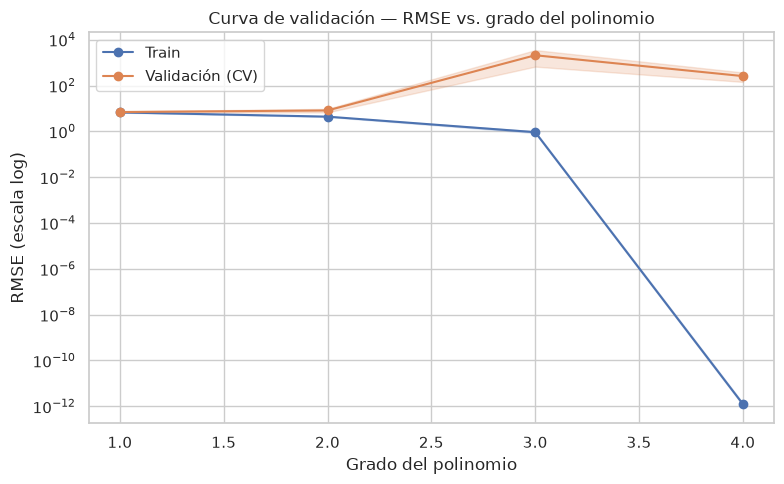

In [9]:
rango_grados = [1, 2, 3, 4]

train_scores, test_scores = validation_curve(
    estimator=pipeline_poly,  # reutiliza el pipeline de la Actividad 1 (scaler=StandardScaler fijo)
    X=X_train, y=y_train,
    param_name="preprocesamiento__num__poly__degree",
    param_range=rango_grados,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

graficar_curva_validacion(
    rango_grados, -train_scores, -test_scores,
    xlabel="Grado del polinomio",
    titulo="Curva de validación — RMSE vs. grado del polinomio",
    log_scale=True,
)


**Análisis (Actividad 2).**

La curva confirma, ahora de forma visual, exactamente lo que se vio en la tabla de la
Actividad 1:

- **Grado 1:** las dos líneas (train y validación) están cerca una de la otra y ambas en la
  parte baja de la gráfica (RMSE ≈ 6.7 en train, ≈ 7.0 en validación). Esta es la zona sana:
  el modelo no está ni subajustado ni sobreajustado, generaliza bien.
- **Grado 2:** la línea de train sigue bajando (≈ 4.4), pero la de validación ya empieza a
  subir (≈ 8.2) y su banda de variabilidad (± 1 desviación estándar) se ensancha. **Este es el
  punto donde se evidencia el inicio del sobreajuste**: el modelo sigue "mejorando" en los
  datos que ve, pero empeora en datos que no ha visto.
- **Grados 3 y 4:** el train colapsa a prácticamente 0 (ajuste perfecto / interpolación) justo
  cuando la validación se dispara a cientos o miles de unidades de RMSE, con una desviación
  estándar entre folds enorme (el modelo ni siquiera es consistente entre folds: cada
  subconjunto de entrenamiento produce un ajuste completamente distinto). La brecha entre las
  dos líneas, que es la forma más directa de "ver" el sobreajuste, pasa de ser casi nula en
  grado 1 a ser de varios órdenes de magnitud en grado 3.

En términos del trade-off sesgo-varianza: subir de grado 1 a grado 4 reduce el sesgo de forma
monótona (el modelo se ajusta cada vez mejor a los datos que ve, el error de train baja sin
parar), pero la varianza crece de forma explosiva a partir de grado 2 y domina por completo el
error total a partir de grado 3. El punto óptimo — donde la suma de sesgo y varianza es
mínima — es grado 1 para este dataset, lo cual es consistente con el modelo seleccionado como
mejor en la Actividad 1.

## <a id="actividad3"></a> Actividad 3 — Regresión regularizada (Ridge / Lasso)

**Qué pide el enunciado:** pipelines con regularización L2 (Ridge) y L1 (Lasso), incluyendo el
parámetro de penalización (`alpha`) y distintas estrategias de escalamiento como
hiperparámetros en `GridSearchCV`; comparar contra un modelo **sin regularización**; analizar
el efecto de la penalización sobre generalización y magnitud de coeficientes; en Lasso,
examinar qué variables quedan en cero (selección automática de características).

**Decisiones de diseño** (contrastadas contra la práctica de clase de regresión regularizada,
`P6_Regresión regularizada`, que sigue el mismo flujo Ridge/Lasso + `GridSearchCV`):

- **Rango de `alpha`: `np.logspace(-3, 3, 13)`** para ambos modelos, siguiendo exactamente la
  sugerencia del ejercicio de esa práctica (explorar el efecto de la regularización en escala
  logarítmica, de `10⁻³` a `10³`). Se verificó primero con una búsqueda exploratoria manual que
  este rango efectivamente contiene el óptimo de ambos modelos con margen a cada lado (no se
  queda pegado a ningún extremo de la grilla).
- **Escalador como hiperparámetro: `StandardScaler` vs. `MinMaxScaler`.** A diferencia de la
  regresión sin regularizar (Actividad 1), acá el escalador **sí** puede cambiar el resultado:
  la penalización se aplica por igual a todos los coeficientes, así que si una variable queda
  en una escala mucho más grande que otra, su coeficiente se penaliza de forma desproporcionada
  respecto al resto. Por eso tiene sentido dejar que `GridSearchCV` decida cuál conviene más,
  en vez de asumirlo.
- **`cv=kfold`** con `KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` definido una
  sola vez en la configuración del entorno, en vez de pasar `cv=5`: es el mismo patrón que usa
  `P6_Regresión regularizada` (allá con `n_splits=10`), más explícito y reproducible que dejar
  que `GridSearchCV` arme los folds internamente.

In [10]:
preprocesamiento_lineal = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),  # valor inicial; el grid prueba ambas opciones
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

# --- Modelo base: regresión lineal SIN regularización (referencia para el punto 3) ---
pipeline_base = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", LinearRegression()),
])
param_grid_base = {
    "preprocesamiento__num": [StandardScaler(), MinMaxScaler()],
}
grid_base = GridSearchCV(
    pipeline_base, param_grid_base, cv=kfold,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# --- Ridge (L2) ---
pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", Ridge(random_state=RANDOM_STATE)),
])
param_grid_ridge = {
    "preprocesamiento__num": [StandardScaler(), MinMaxScaler()],
    "regresor__alpha": np.logspace(-3, 3, 13),
}
grid_ridge = GridSearchCV(
    pipeline_ridge, param_grid_ridge, cv=kfold,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# --- Lasso (L1) ---
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", Lasso(random_state=RANDOM_STATE, max_iter=10000)),
])
param_grid_lasso = {
    "preprocesamiento__num": [StandardScaler(), MinMaxScaler()],
    "regresor__alpha": np.logspace(-3, 3, 13),
}
grid_lasso = GridSearchCV(
    pipeline_lasso, param_grid_lasso, cv=kfold,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

grid_base.fit(X_train, y_train)
grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)

print("Base  -> mejores hiperparámetros:", grid_base.best_params_, f"| RMSE_cv={-grid_base.best_score_:.4f}")
print("Ridge -> mejores hiperparámetros:", grid_ridge.best_params_, f"| RMSE_cv={-grid_ridge.best_score_:.4f}")
print("Lasso -> mejores hiperparámetros:", grid_lasso.best_params_, f"| RMSE_cv={-grid_lasso.best_score_:.4f}")


Base  -> mejores hiperparámetros: {'preprocesamiento__num': StandardScaler()} | RMSE_cv=6.9603
Ridge -> mejores hiperparámetros: {'preprocesamiento__num': MinMaxScaler(), 'regresor__alpha': np.float64(3.1622776601683795)} | RMSE_cv=6.9107
Lasso -> mejores hiperparámetros: {'preprocesamiento__num': MinMaxScaler(), 'regresor__alpha': np.float64(0.01)} | RMSE_cv=6.9014


In [11]:
evaluar_modelo("Lineal sin regularización", grid_base.best_estimator_, X_train, y_train, X_test, y_test)
evaluar_modelo("Ridge (L2)", grid_ridge.best_estimator_, X_train, y_train, X_test, y_test)
evaluar_modelo("Lasso (L1)", grid_lasso.best_estimator_, X_train, y_train, X_test, y_test)
pd.DataFrame(resultados_modelos).set_index("modelo")


,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
modelo,,,,,,
Regresión polinomial (GridSearchCV),6.727844,5.091492,0.479034,6.346607,5.094928,0.476326
Lineal sin regularización,6.727844,5.091492,0.479034,6.346607,5.094928,0.476326
Ridge (L2),6.751645,5.107112,0.475341,6.346969,5.106127,0.476266
Lasso (L1),6.762295,5.104611,0.473685,6.349347,5.111241,0.475873


In [12]:
def mejor_alpha_con_scaler(grid, scaler_cls):
    """Entre los resultados de un GridSearchCV que exploró alpha y escalador a la vez,
    devuelve el mejor alpha encontrado específicamente para `scaler_cls`."""
    res = pd.DataFrame(grid.cv_results_)
    mask = res["param_preprocesamiento__num"].apply(lambda s: isinstance(s, scaler_cls))
    fila = res[mask].sort_values("mean_test_score", ascending=False).iloc[0]
    return fila["param_regresor__alpha"]


# El escalador ganador global de Ridge/Lasso fue MinMaxScaler (celda anterior), pero sus
# coeficientes quedan en una escala distinta a la del modelo base (que usa StandardScaler) y
# no son comparables en magnitud absoluta entre sí. Para una comparación justa de qué tanto
# "encoge" cada tipo de regularización los coeficientes, se refitean Ridge y Lasso con el
# mismo StandardScaler del modelo base, usando el mejor alpha que cada uno encontró bajo ese
# escalador (no el ganador global, que usa MinMaxScaler).
alpha_ridge_std = mejor_alpha_con_scaler(grid_ridge, StandardScaler)
alpha_lasso_std = mejor_alpha_con_scaler(grid_lasso, StandardScaler)

modelo_ridge_std = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", Ridge(alpha=alpha_ridge_std, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)
modelo_lasso_std = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("regresor", Lasso(alpha=alpha_lasso_std, random_state=RANDOM_STATE, max_iter=10000)),
]).fit(X_train, y_train)

coefs_base = obtener_coeficientes(grid_base.best_estimator_)  # ya usa StandardScaler
coefs_ridge = obtener_coeficientes(modelo_ridge_std)
coefs_lasso = obtener_coeficientes(modelo_lasso_std)

comparacion_coefs = pd.DataFrame({
    "|coef|_base": coefs_base.set_index("variable")["coef_abs"],
    "|coef|_ridge": coefs_ridge.set_index("variable")["coef_abs"],
    "|coef|_lasso": coefs_lasso.set_index("variable")["coef_abs"],
})
print(f"(alpha usado -> ridge: {alpha_ridge_std:.4f} | lasso: {alpha_lasso_std:.4f}, ambos con StandardScaler)\n")
print("Suma de |coeficientes| por modelo (mismo escalador en los tres, comparación justa):")
print(comparacion_coefs.sum())

# ¿Qué variables quedaron exactamente en 0 en Lasso? (selección automática de características)
variables_eliminadas_lasso = coefs_lasso[coefs_lasso["coeficiente"] == 0]
print(f"\nLasso llevó {len(variables_eliminadas_lasso)} de {len(coefs_lasso)} variables exactamente a 0:")
variables_eliminadas_lasso


(alpha usado -> ridge: 31.6228 | lasso: 0.0316, ambos con StandardScaler)

Suma de |coeficientes| por modelo (mismo escalador en los tres, comparación justa):
|coef|_base     48.891857
|coef|_ridge    37.754316
|coef|_lasso    32.291511
dtype: float64

Lasso llevó 11 de 43 variables exactamente a 0:


,variable,coeficiente,coef_abs
32,num__presion_max,-0.0,0.0
33,num__viento_media,-0.0,0.0
34,num__rafaga_max,0.0,0.0
35,cat__mes_enero,-0.0,0.0
36,cat__mes_septiembre,0.0,0.0
37,cat__mes_octubre,-0.0,0.0
38,cat__sector_viento_N,0.0,0.0
39,cat__sector_viento_NE,0.0,0.0
40,cat__sector_viento_O,0.0,0.0
41,cat__sector_viento_SE,-0.0,0.0


**Análisis (Actividad 3).**

En desempeño puro, los tres modelos son prácticamente indistinguibles en test (RMSE ≈ 6.35,
R² ≈ 0.476 los tres). Esto tiene sentido: sin expansión polinomial, el conjunto de 43
variables (22 numéricas + dummies categóricas) ya generalizaba bien en la Actividad 1 — no
había un problema de sobreajuste que la regularización tuviera que "rescatar" acá (ese
problema aparece en la Actividad 4, al combinar regularización con polinomios). Donde sí se
ven diferencias es en la validación cruzada y en los coeficientes:

- **RMSE en validación cruzada:** Lasso (≈ 6.90) < Ridge (≈ 6.91) < sin regularizar (≈ 6.96).
  La mejora es pequeña pero consistente: incluso en un modelo que no estaba sobreajustado, un
  poco de regularización ayuda a generalizar mejor, probablemente por las variables
  redundantes/correlacionadas entre las 22 numéricas (por ejemplo, `presion_media`,
  `presion_min`, `presion_max` y `presion_desv` capturan información parecida).
- **Magnitud de los coeficientes (con el mismo escalador en los tres, para que sea
  comparable):** la suma de `|coeficiente|` baja de forma monótona con la regularización:
  ≈ 48.9 (sin regularizar) → ≈ 37.8 (Ridge) → ≈ 32.3 (Lasso). Ridge encoge todos los
  coeficientes de forma continua sin anular ninguno; Lasso encoge aún más **y además** lleva
  **11 de 43** variables exactamente a cero: 3 numéricas (`presion_max`, `viento_media`,
  `rafaga_max`), 3 categorías de `mes` (enero, septiembre, octubre) y 5 de las 7 categorías de
  `sector_viento` (N, NE, O, SE, SO). Todo esto sin perder desempeño — de hecho, fue el de
  mejor RMSE en CV de los tres.
- **Interpretación de las variables eliminadas por Lasso:** el patrón más llamativo es que
  Lasso descarta **la mayoría de las categorías de `sector_viento`** (5 de 7), sugiriendo que,
  una vez se controla por la velocidad y ráfagas del viento (que sí se conservan), *la
  dirección* del viento aporta poca información adicional para predecir la temperatura máxima
  del día siguiente. También descarta 3 de las 11 categorías de `mes`, mientras conserva
  `estacion_anio`, lo cual sugiere que buena parte de la señal estacional ya la captura esa
  variable más agregada, y el detalle fino de "en qué mes exacto" aporta menos una vez esa
  variable está presente. En la familia de variables de presión, se elimina `presion_max` pero
  se conservan `presion_media`, `presion_min` y `presion_desv` (todas correlacionadas entre
  sí), consistente con lo que predice la teoría: cuando hay variables altamente
  correlacionadas, Lasso tiende a quedarse con algunas representantes de cada grupo y
  descartar el resto, mientras que Ridge reparte el efecto entre todas ellas sin descartar
  ninguna. Esto coincide con el mismo patrón que se observa en la
  práctica de clase de regresión regularizada (`P6`, sobre el dataset de venta de inmuebles):
  *"Aunque Lasso logra un modelo más simple al eliminar algunas variables, el desempeño
  predictivo es prácticamente idéntico al de Ridge."*

**Nota metodológica:** el escalador que ganó globalmente en `GridSearchCV` para Ridge y Lasso
fue `MinMaxScaler` (ligeramente mejor en RMSE de validación cruzada que `StandardScaler`), y
esos son los modelos reportados en la tabla de desempeño de arriba. Sin embargo, para comparar
la *magnitud* de los coeficientes entre los tres modelos de forma justa, fue necesario fijar
el mismo escalador (`StandardScaler`) en los tres: comparar coeficientes de modelos ajustados
sobre escalas distintas no es una comparación válida, aunque el desempeño (RMSE/MAE/R²) sí lo
sea porque no depende de la escala de los coeficientes, solo de las predicciones.

**Conclusión de la Actividad 3:** dado que el desempeño de los tres modelos es equivalente en
test, la elección entre ellos en este punto es más una cuestión de interpretabilidad
(Lasso, con 11 variables menos, es más fácil de explicar a AlpesPlanck) que de precisión
predictiva. La pregunta más interesante — si la regularización puede controlar el sobreajuste
que sí vimos en la Actividad 1 cuando se combina con polinomios de grado alto — se responde en
la Actividad 4.

## <a id="actividad4"></a> Actividad 4 — Regresión polinomial regularizada

**Qué pide el enunciado:** combinar generación de características polinomiales con un modelo
regularizado (Ridge o Lasso), explorando grado del polinomio, `alpha` y escalamiento en la
misma búsqueda; evaluar con RMSE/MAE/R² por validación cruzada; discutir si la regularización
permite controlar el sobreajuste al aumentar la complejidad.

> **TODO:** decidir y justificar Ridge o Lasso para este modelo (o ambos, si el tiempo de
> cómputo lo permite) y el rango de grados/alphas a explorar. El enunciado advierte que esta
> búsqueda puede tardar bastante, así que conviene empezar con una grilla pequeña y ampliarla solo si
> el tiempo lo permite.

In [13]:
preprocesamiento_poly_reg = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),  # placeholder; el grid prueba otras opciones
    ]), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

# TODO: elegir Ridge o Lasso como regresor de este pipeline
pipeline_poly_reg = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly_reg),
    ("regresor", Ridge(random_state=RANDOM_STATE)),  # TODO: o Lasso(random_state=RANDOM_STATE, max_iter=10000)
])

param_grid_poly_reg = {
    "preprocesamiento__num__poly__degree": [...],  # TODO
    "preprocesamiento__num__scaler": [...],          # TODO
    "regresor__alpha": [...],                        # TODO
}

grid_poly_reg = GridSearchCV(
    pipeline_poly_reg, param_grid_poly_reg, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True,
)

# TODO: descomentar (grilla combinada; puede tardar bastante, ver nota del enunciado)
# grid_poly_reg.fit(X_train, y_train)
# print("Mejores hiperparámetros:", grid_poly_reg.best_params_)


In [14]:
# TODO: descomentar una vez `grid_poly_reg` esté ajustado
# evaluar_modelo("Polinomial regularizado", grid_poly_reg.best_estimator_, X_train, y_train, X_test, y_test)
# pd.DataFrame(resultados_modelos).set_index("modelo")


**Análisis (Actividad 4).**

> **TODO:** discutir si, a igual grado de complejidad, el modelo regularizado generaliza
> mejor que el polinomial sin regularizar de la Actividad 1 (comparar el gap train/test), y si
> la regularización permite usar grados más altos sin que el desempeño en test se deteriore.

## <a id="actividad5"></a> Actividad 5 — Comparación y selección del mejor modelo

**Qué pide el enunciado:** con base en los resultados de los puntos 1, 3 y 4, seleccionar el
mejor modelo considerando no solo el valor promedio de la métrica principal sino también su
estabilidad (desviación estándar en validación cruzada); reportar los mejores hiperparámetros
encontrados y argumentar la elección final.

In [15]:
# Tabla comparativa de RMSE/MAE/R² en train y test para todos los modelos evaluados
if resultados_modelos:
    tabla_comparativa = pd.DataFrame(resultados_modelos).set_index("modelo")
else:
    # Aún no se ha evaluado ningún modelo (celdas TODO pendientes más arriba)
    tabla_comparativa = pd.DataFrame(
        columns=["RMSE_train", "MAE_train", "R2_train", "RMSE_test", "MAE_test", "R2_test"]
    )
tabla_comparativa


,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
modelo,,,,,,
Regresión polinomial (GridSearchCV),6.727844,5.091492,0.479034,6.346607,5.094928,0.476326
Lineal sin regularización,6.727844,5.091492,0.479034,6.346607,5.094928,0.476326
Ridge (L2),6.751645,5.107112,0.475341,6.346969,5.106127,0.476266
Lasso (L1),6.762295,5.104611,0.473685,6.349347,5.111241,0.475873


In [16]:
# TODO: descomentar una vez los GridSearchCV relevantes (poly, base, ridge, lasso, poly_reg)
# estén ajustados, para comparar también la estabilidad en validación cruzada (media ± std).
# resumen_estabilidad = pd.DataFrame([
#     resumen_cv(grid_poly, "Regresión polinomial"),
#     resumen_cv(grid_base, "Lineal sin regularización"),
#     resumen_cv(grid_ridge, "Ridge (L2)"),
#     resumen_cv(grid_lasso, "Lasso (L1)"),
#     resumen_cv(grid_poly_reg, "Polinomial regularizado"),
# ]).set_index("modelo")
# resumen_estabilidad


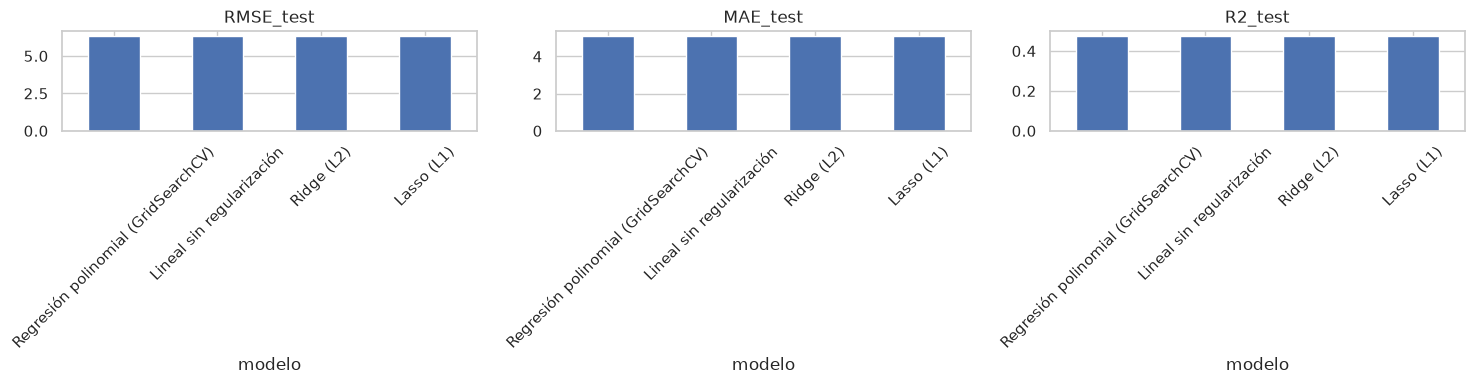

In [17]:
# Comparación visual de RMSE/MAE/R² (test) entre todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["RMSE_test", "MAE_test", "R2_test"]):
    if metrica in tabla_comparativa.columns and not tabla_comparativa.empty:
        tabla_comparativa[metrica].plot(kind="bar", ax=ax, color="#4c72b0")
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Selección del mejor modelo.**

> **TODO:**
> - Reportar, en una tabla o lista, los mejores hiperparámetros encontrados para cada modelo
>   (`grid_XXX.best_params_`).
> - Elegir el modelo final considerando desempeño (RMSE/MAE/R² en test), estabilidad
>   (desviación estándar en CV) y complejidad/interpretabilidad, no solo el mejor promedio.
> - Justificar explícitamente la elección: ¿por qué ese modelo y no el de mejor métrica
>   promedio, si son distintos?

```python
# TODO: fijar aquí el modelo elegido, para usarlo en la Actividad 6
mejor_modelo = None  # TODO: p. ej. grid_ridge.best_estimator_
nombre_mejor_modelo = None  # TODO
```

In [18]:
# TODO: fijar aquí el modelo final elegido en la Actividad 5 (usado en la Actividad 6)
mejor_modelo = None  # TODO: p. ej. grid_ridge.best_estimator_
nombre_mejor_modelo = None  # TODO


## <a id="actividad6"></a> Actividad 6 — Intervalos de confianza (bootstrapping)

**Qué pide el enunciado:** usando el modelo seleccionado en la Actividad 5, aplicar
bootstrapping sobre el conjunto de test (al menos 500 remuestreos) para estimar intervalos de
confianza al 95% de RMSE, MAE y R²; graficar la distribución de los errores y discutir
estabilidad, variabilidad y confiabilidad de las predicciones.

In [19]:
# TODO: descomentar una vez `mejor_modelo` esté definido en la Actividad 5
# boot_df = bootstrap_metricas(mejor_modelo, X_test, y_test, n_iteraciones=500, random_state=RANDOM_STATE)
# boot_df.describe()


In [20]:
# TODO: descomentar una vez `boot_df` exista
# for metrica in ["RMSE", "MAE", "R2"]:
#     lower, upper = intervalo_confianza(boot_df[metrica])
#     print(f"{metrica}: media={boot_df[metrica].mean():.4f} | IC 95% = [{lower:.4f}, {upper:.4f}]")


In [21]:
# TODO: descomentar una vez `boot_df` exista
# graficar_distribucion_bootstrap(boot_df)


**Análisis (Actividad 6).**

> **TODO:** interpretar el ancho de los intervalos de confianza obtenidos (¿son estrechos y
> por tanto indican estabilidad, o amplios e indican alta variabilidad?), qué tan simétricas o
> sesgadas son las distribuciones de los errores, y qué implicaciones tiene esto para la
> confiabilidad de las predicciones que AlpesPlanck usaría en producción.

## <a id="analisis"></a> Análisis de resultados

### Análisis cuantitativo

- **¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**
  > _TODO_

- **¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**
  > _TODO_

- **¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.**
  > _TODO_

- **Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**
  > _TODO_

- **¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**
  > _TODO_

- **¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?**
  > _TODO_

### Análisis cualitativo

- **¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**
  > _TODO_

- **¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?**
  > _TODO_

- **¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**
  > _TODO_

- **¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?**
  > _TODO_

- **¿Mayor precisión implica necesariamente mayor valor para la organización?**
  > _TODO_

- **¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.**
  > _TODO_

### Reflexión conceptual

- **¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**
  > _TODO_

- **¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**
  > _TODO_

- **Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.**
  > _TODO_

## <a id="iag"></a> Uso de herramientas de IA generativa

### Entrada 1 — Montaje del esqueleto del laboratorio

**Declaración del uso.** Herramienta: Claude (Anthropic), vía Claude Code, con acceso directo
al repositorio (lectura del Laboratorio 1, creación de archivos, ejecución de comandos en el
entorno local). Tipo de uso: generación de un esqueleto inicial de proyecto y de notebook
(estructura de carpetas, pipeline de limpieza reutilizado del Laboratorio 1, definición de
funciones auxiliares de evaluación/graficación/bootstrapping, y celdas `TODO` para cada
actividad y pregunta de análisis del enunciado). No se usó para tomar decisiones de modelado
(rangos de hiperparámetros, elección de modelo final, interpretación de resultados): esas
quedaron explícitamente como `TODO` para el equipo.

**Prompt utilizado (resumido).** *"Ayúdame a montar el esqueleto del Laboratorio 2 de forma
profesional: revisa el enunciado del repositorio del curso, reutiliza lo que sea reutilizable
del Laboratorio 1 (mismo caso, mismos datos) y organiza el proyecto (estructura de carpetas,
requirements, notebook con las secciones de cada actividad y las preguntas de análisis ya
planteadas, sin resolver el modelado)."*

**Análisis crítico del resultado.**
- ¿Qué partes fueron correctas y útiles? La reutilización del pipeline de limpieza del
  Laboratorio 1 (sin fuga de datos) y las funciones auxiliares (evaluación de métricas,
  bootstrapping, extracción de coeficientes) son correctas y evitan reescribir lógica ya
  validada en el laboratorio anterior.
- ¿Qué decisiones técnicas quedaron pendientes de revisión propia? Los rangos de
  hiperparámetros sugeridos en los `TODO` (grados de polinomio, valores de `alpha`, folds de
  CV) son solo placeholders de ejemplo; el equipo debe definirlos con criterio propio y
  justificarlos, así como todas las interpretaciones de la sección de Análisis de resultados.

**Aportes propios del equipo.**
> _TODO: completar aquí, tras desarrollar las Actividades 1 a 6, qué se desarrolló, modificó o
> decidió por cuenta propia del equipo (rangos de hiperparámetros elegidos y por qué, modelo
> final seleccionado, interpretación de resultados, etc.)._

### Entrada 2 — Desarrollo de las actividades de modelado

> _TODO: documentar aquí (siguiendo el mismo formato: declaración del uso, prompts utilizados,
> análisis crítico y aportes propios) cualquier uso adicional de IA generativa durante el
> desarrollo de las Actividades 1 a 6 y de la sección de Análisis de resultados._

## Entregables y checklist final

- [ ] Notebook exportado también a `.html` (`jupyter nbconvert --to html sm.jimenezp1_j.trivinon.ipynb`).
- [ ] Todas las celdas ejecutadas y con sus salidas visibles (sin celdas `TODO` sin resolver).
- [ ] Tabla comparativa de modelos (Actividad 5) con los mejores hiperparámetros reportados.
- [ ] Intervalos de confianza (Actividad 6) calculados con al menos 500 remuestreos.
- [ ] Todas las preguntas de la sección "Análisis de resultados" respondidas.
- [ ] Sección "Uso de herramientas de IA generativa" completa (ambas entradas).
- [ ] Video explicativo grabado (máx. 3 minutos), orientado al ingeniero de ML que lidera el equipo de AlpesPlanck.
- [ ] Integrantes registrados en el grupo GL2 en BloqueNeón.

**Fecha límite: 14 de septiembre, 20:00** (penalización del 30% hasta el 15 de septiembre,
2:00 a.m.; después de esa hora, la entrega se califica con 0).